In [1]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from mts_study import *

# Setup

In [3]:
# plot setup
plt.rcParams['figure.figsize'] = [14,8]

color_map = {
    "libfabric": "blue",
    "native": "orange",
    "ucx": "green",
    "libfabric-fix": "red",
}

sns.set_theme(style="whitegrid")

data_dir = "../data/mts-study"

# Transfers

## Device to Device Inter-Host

In [4]:
config = {"libraries":[Library.libfabric, Library.native], "tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}
data, perf, _ = load_data(f"{data_dir}/d2d-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device to Device Inter-Host transfers

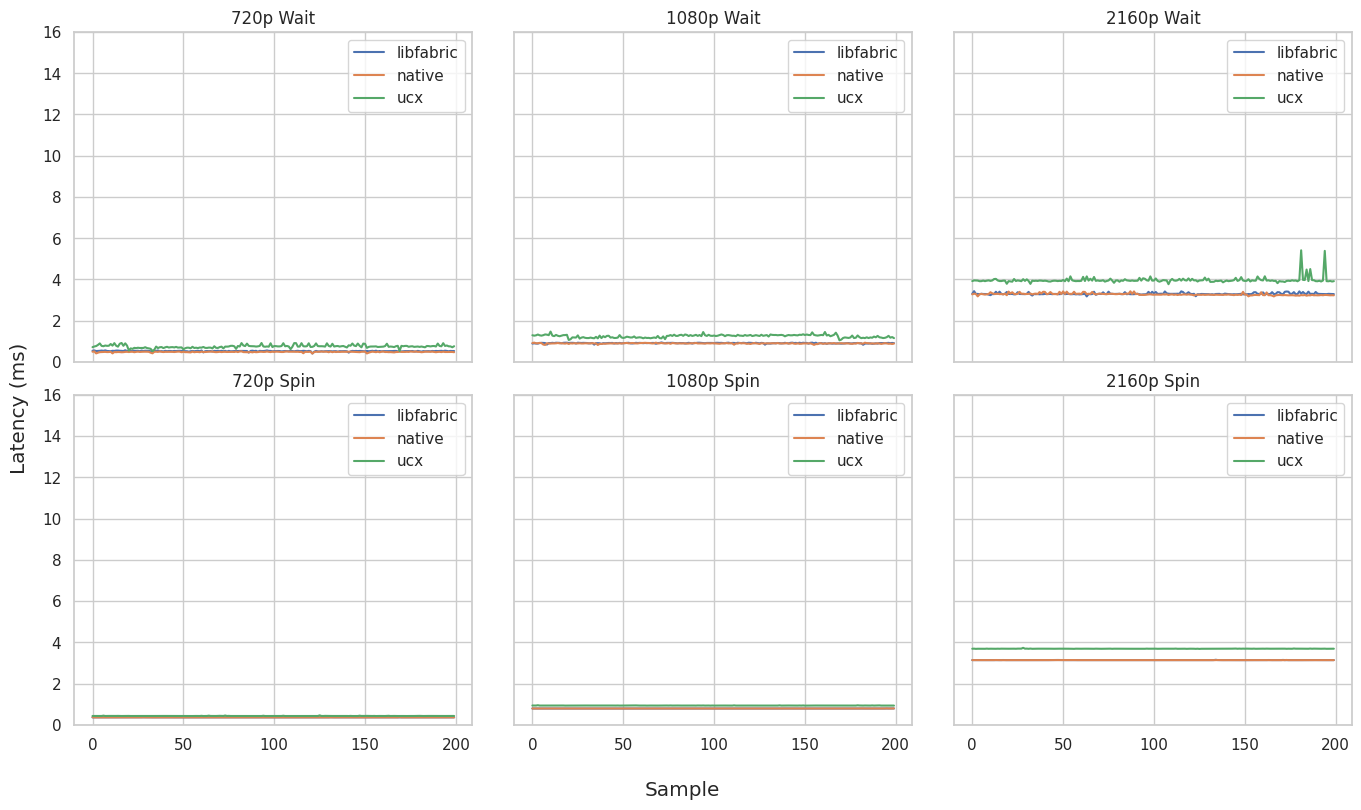

In [5]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in [Library.libfabric,  Library.native]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/2/1e6, label=f"{library.value}")
        axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2d, Transport.none, TransferMode.reflect)]/2/1e6, label=f"ucx")
        axs[j][i].legend()

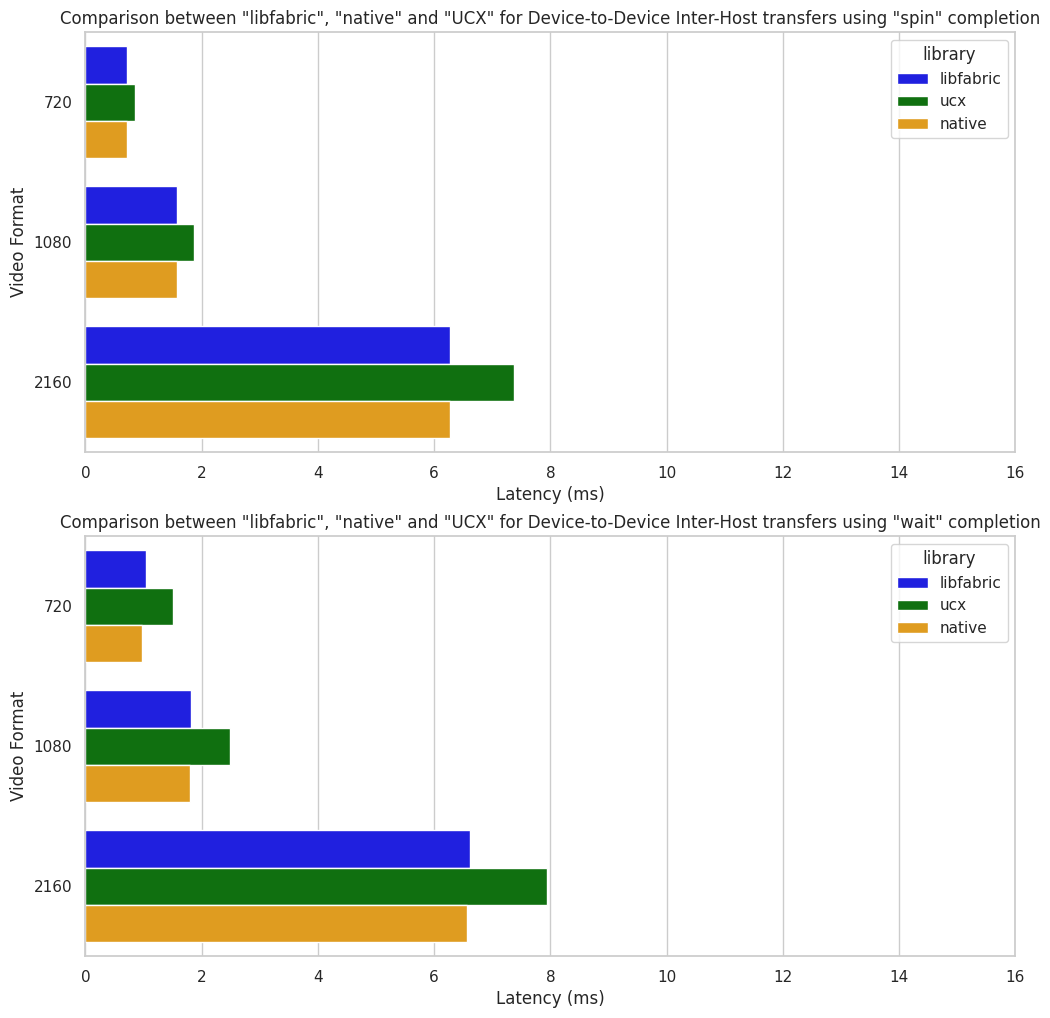

In [6]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

comps=[Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "native" and "UCX" for Device-to-Device Inter-Host transfers using "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [7]:
data_columns = ["format", "library", "completion"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["format","completion"])
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["format","completion"])
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["format","completion"])

In [8]:
table= GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (6, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ libfabric ┆ Spin       ┆ 0.7221   ┆ 0.7301  ┆ 0.0012  ┆ 0.046     │
│ 720    ┆ native    ┆ Spin       ┆ 0.7204   ┆ 0.7393  ┆ 0.0026  ┆ 0.0457    │
│ 720    ┆ ucx       ┆ Spin       ┆ 0.8582   ┆ 0.9163  ┆ 0.0076  ┆ 0.0574    │
│ 720    ┆ libfabric ┆ Wait       ┆ 1.0491   ┆ 1.134   ┆ 0.0339  ┆ 0.0098    │
│ 720    ┆ native    ┆ Wait       ┆ 0.9663   ┆ 1.02    ┆ 0.0334  ┆ 0.0109    │
│ 720    ┆ ucx       ┆ Wait       ┆ 1.5023   ┆ 1.8341  ┆ 0.1445  ┆ 0.0125    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eacfdd88d0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eacfda3610>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1280x720 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eadc0b8810>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='nor

In [9]:
table= GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1920x1080 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (6, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ libfabric ┆ Spin       ┆ 1.5819   ┆ 1.5921  ┆ 0.0014  ┆ 0.102     │
│ 1080   ┆ native    ┆ Spin       ┆ 1.5805   ┆ 1.5955  ┆ 0.0017  ┆ 0.1001    │
│ 1080   ┆ ucx       ┆ Spin       ┆ 1.8682   ┆ 1.8985  ┆ 0.0046  ┆ 0.1162    │
│ 1080   ┆ libfabric ┆ Wait       ┆ 1.8195   ┆ 1.888   ┆ 0.0336  ┆ 0.01      │
│ 1080   ┆ native    ┆ Wait       ┆ 1.7925   ┆ 1.8695  ┆ 0.0327  ┆ 0.0127    │
│ 1080   ┆ ucx       ┆ Wait       ┆ 2.4946   ┆ 2.9406  ┆ 0.1398  ┆ 0.0125    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eacfda3510>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eacfdc7bd0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1920x1080 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eacfda3590>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='no

In [10]:
table= GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
     .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (6, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ libfabric ┆ Spin       ┆ 6.2767   ┆ 6.306   ┆ 0.003   ┆ 0.3789    │
│ 2160   ┆ native    ┆ Spin       ┆ 6.2742   ┆ 6.2885  ┆ 0.0017  ┆ 0.3799    │
│ 2160   ┆ ucx       ┆ Spin       ┆ 7.3814   ┆ 7.4675  ┆ 0.0083  ┆ 0.4459    │
│ 2160   ┆ libfabric ┆ Wait       ┆ 6.6121   ┆ 6.8603  ┆ 0.085   ┆ 0.01      │
│ 2160   ┆ native    ┆ Wait       ┆ 6.5588   ┆ 6.846   ┆ 0.0973  ┆ 0.0114    │
│ 2160   ┆ ucx       ┆ Wait       ┆ 7.9395   ┆ 10.8253 ┆ 0.3295  ┆ 0.0125    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eacfd46710>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eacf1131d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 3840x2160 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eacfdad990>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='no

## Device to Host 2 Host to Device Inter-host

In [11]:
config = {"libraries":[Library.libfabric, Library.native],"tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d, Movement.dh2hd], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}

# load data
data, perf, pcie = load_data(f"{data_dir}/dh2hd-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device-to-Host-to-Host-to-Device transfers

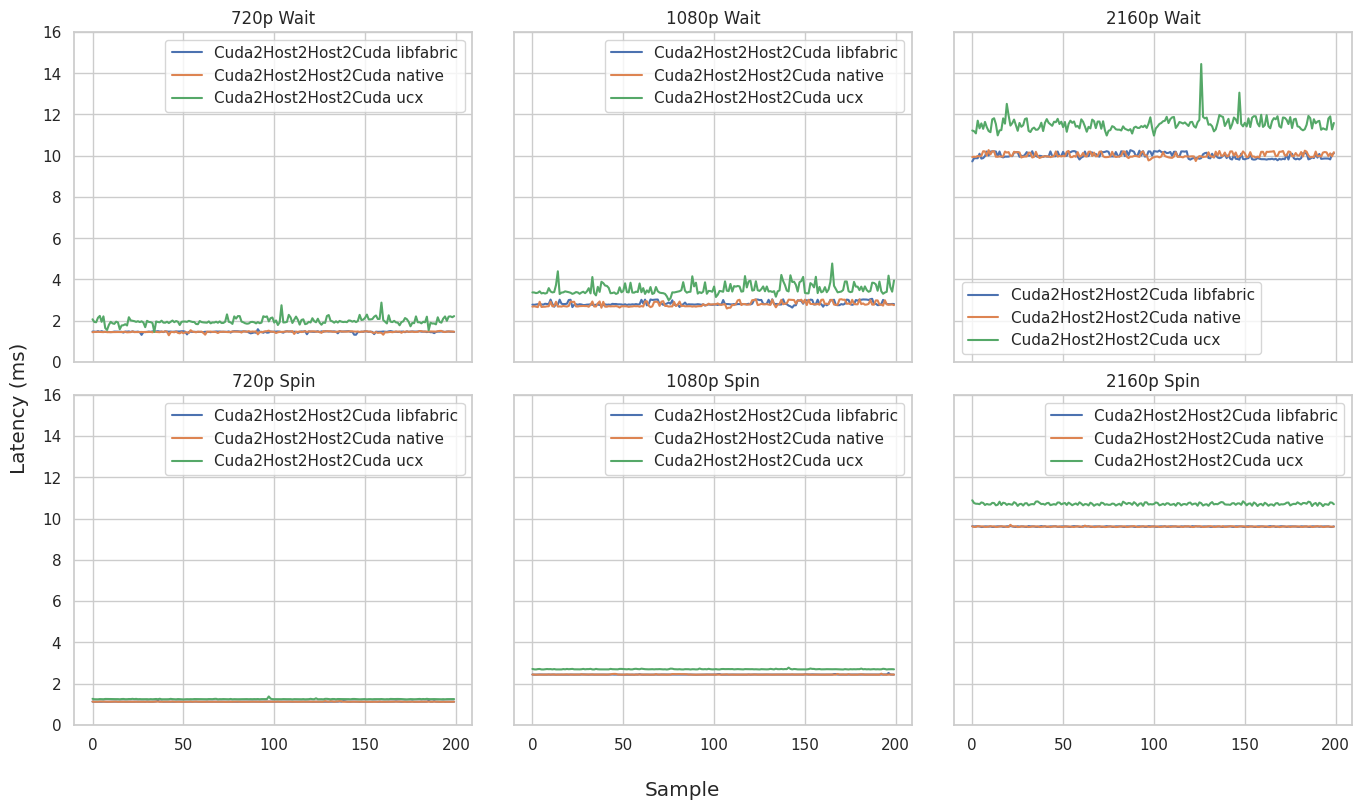

In [12]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in config["libraries"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} {library.value}")
        axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.dh2hd, Transport.none, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} ucx")
        axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using libfabric

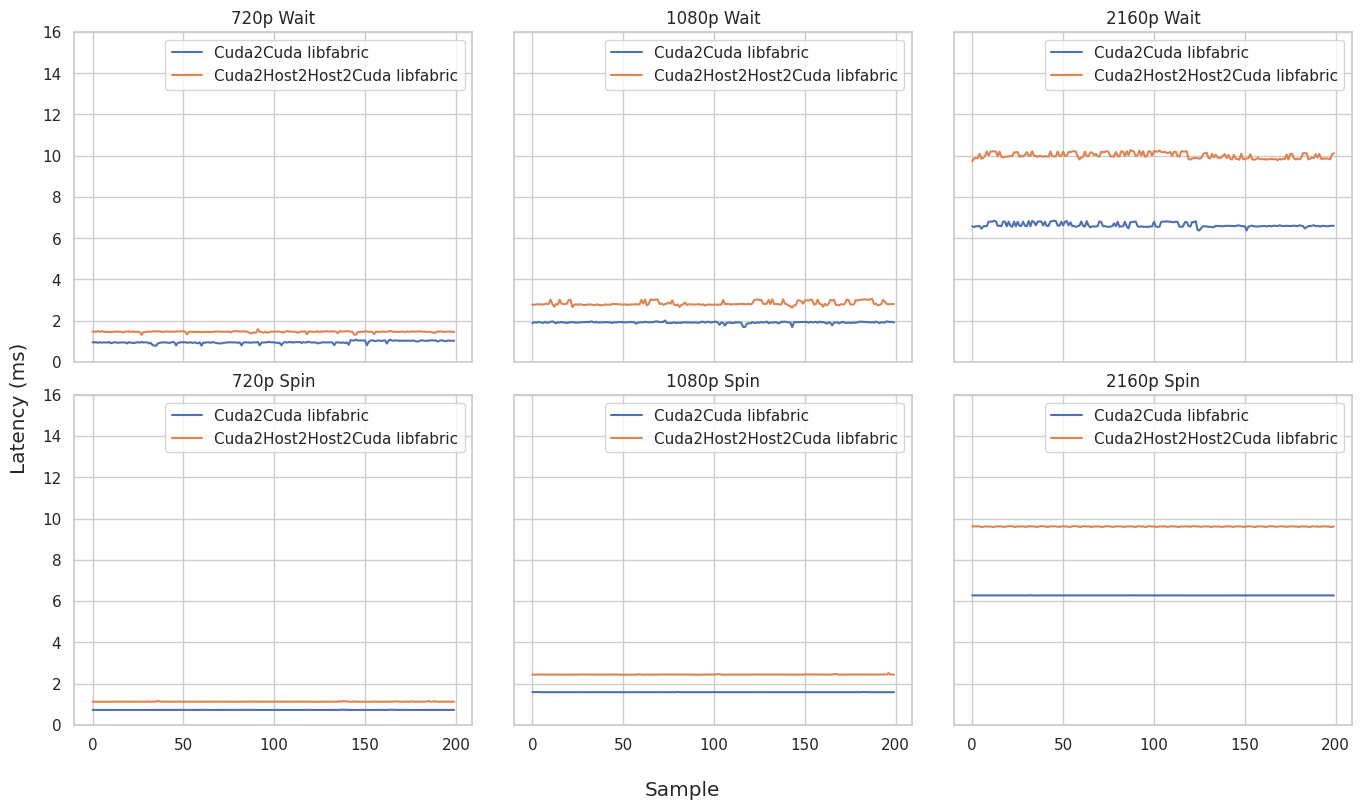

In [13]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.libfabric

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using native

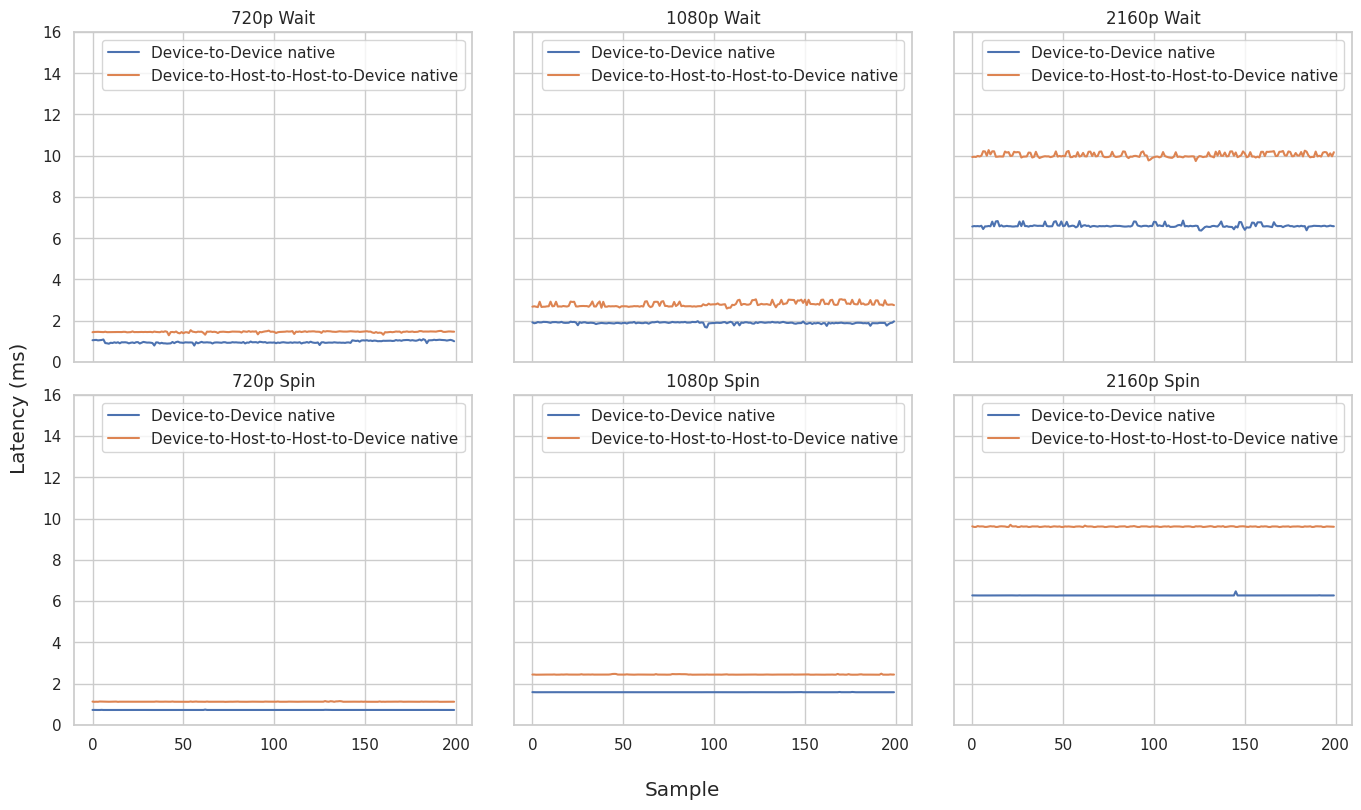

In [14]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.native

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using UCX

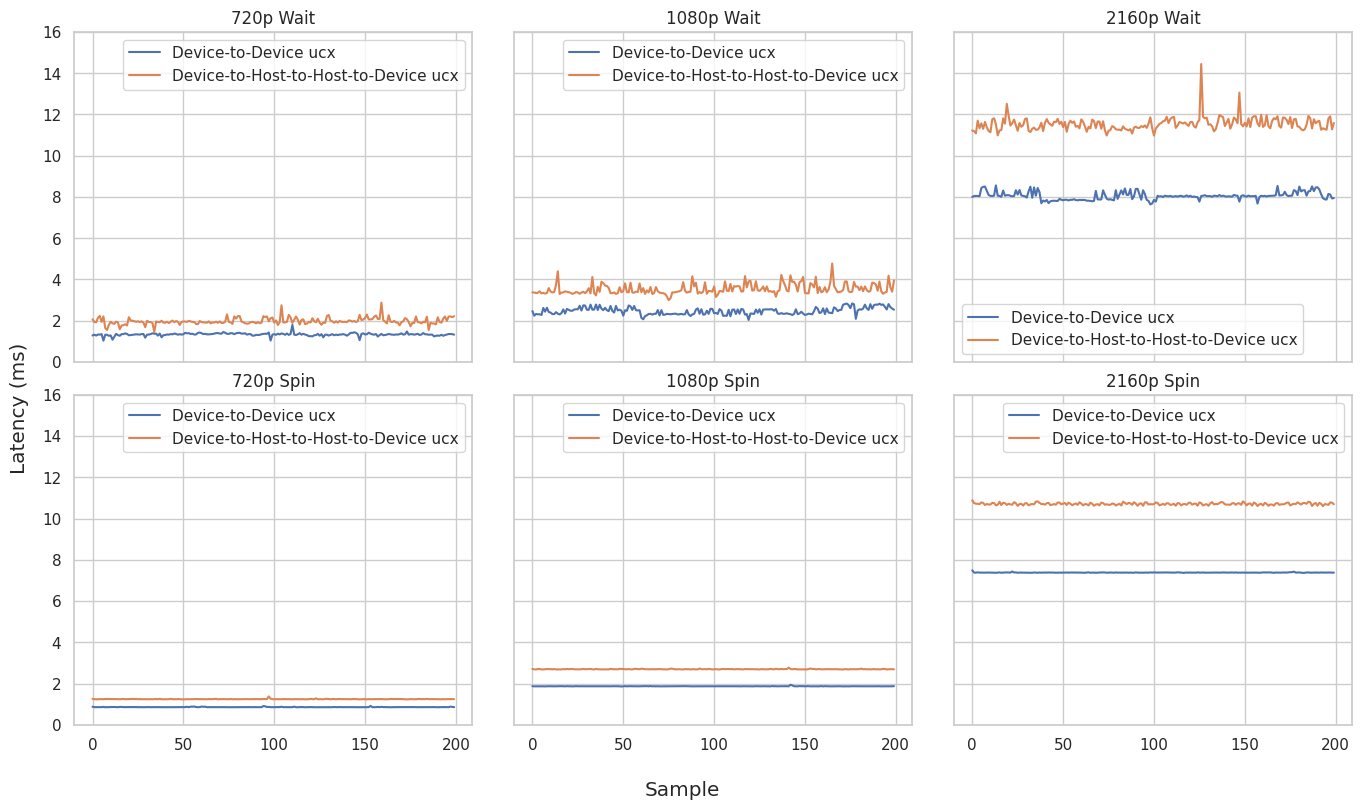

In [15]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, movement, Transport.none, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} ucx")
            axs[j][i].legend()
        

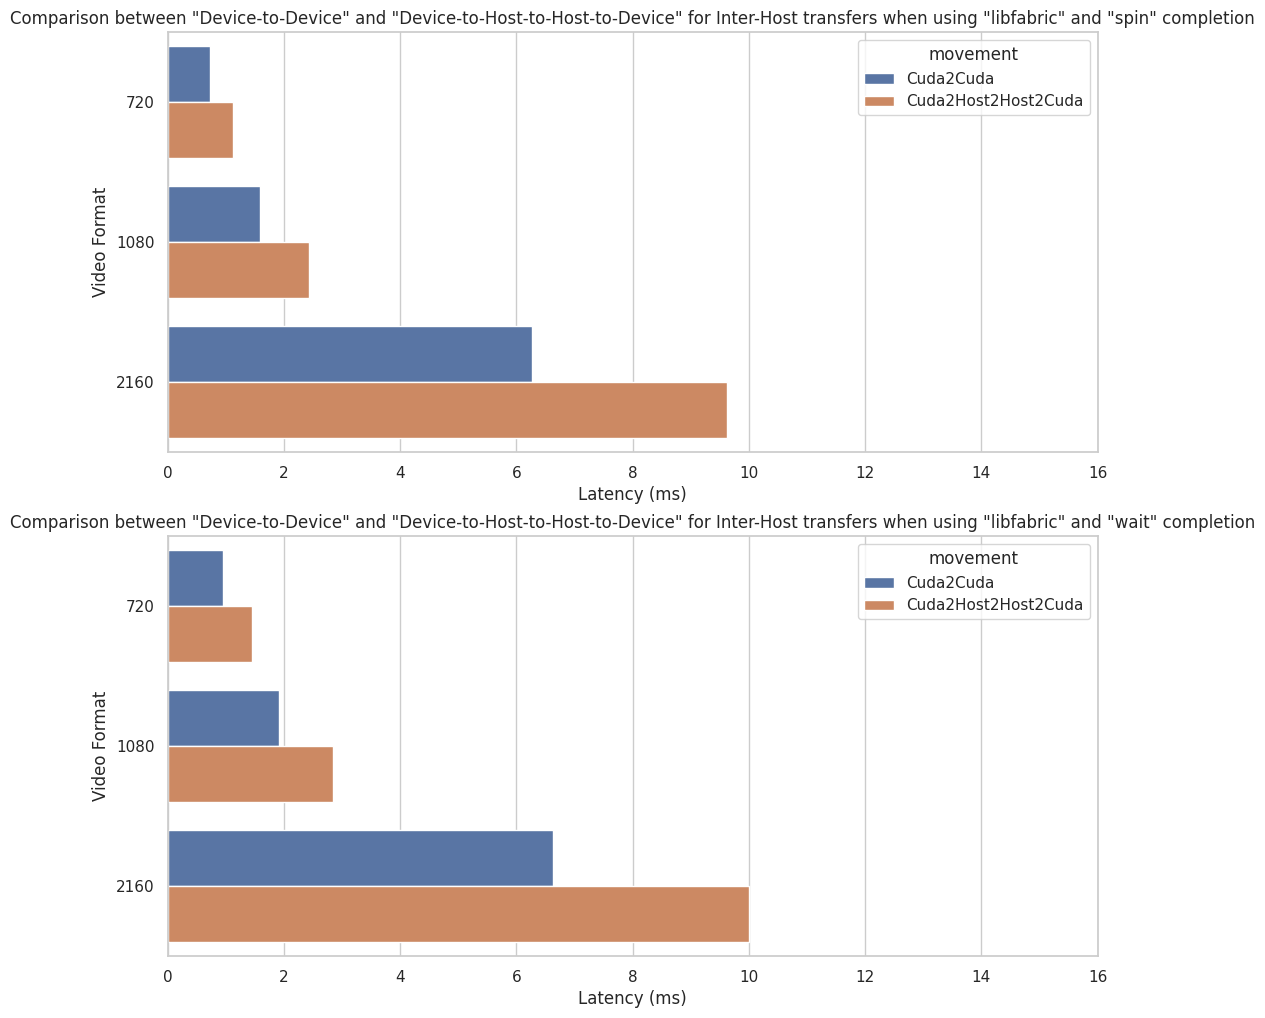

In [16]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('movement').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "libfabric" and "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value, pl.col("library") == "libfabric"), x='lat_mean', y="format", hue='movement', orient='h', ax=axs[i]);

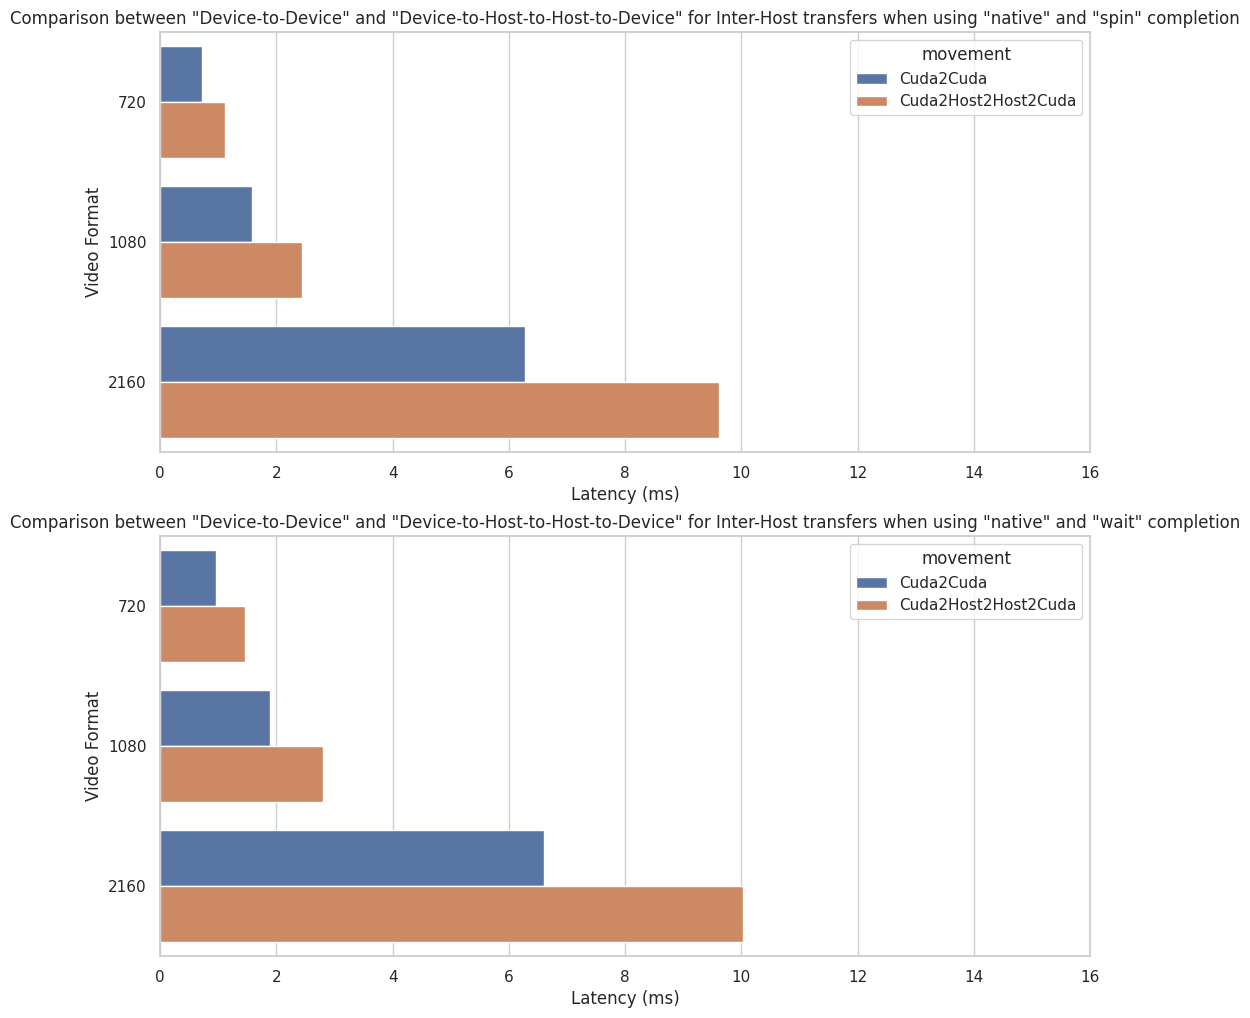

In [17]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('movement').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "native" and "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value, pl.col("library") == "native"), x='lat_mean', y="format", hue='movement', orient='h', ax=axs[i]);

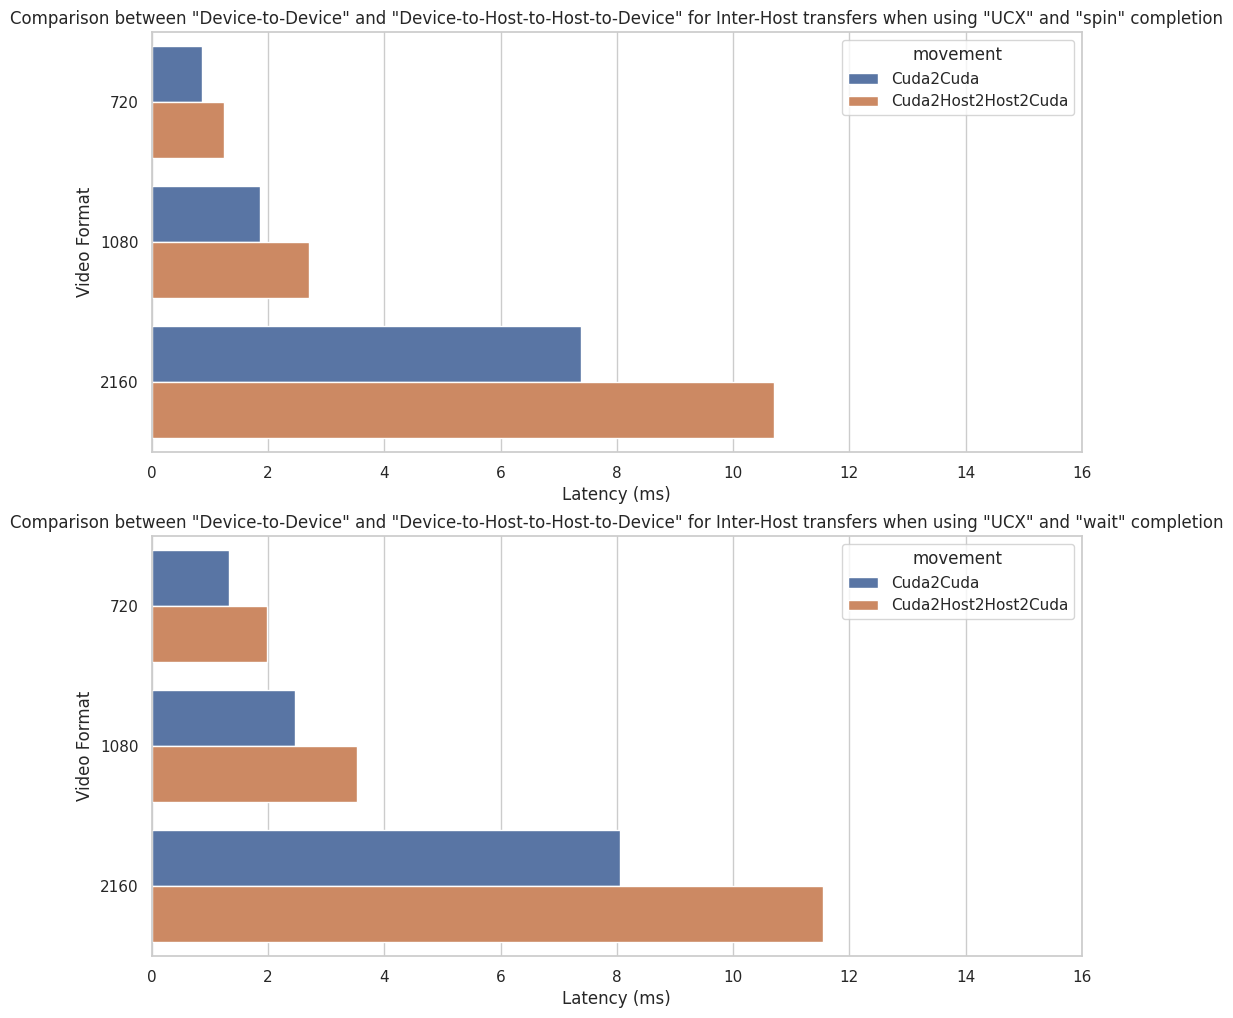

In [18]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('movement').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "UCX" and "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value, pl.col("library") == "ucx"), x='lat_mean', y="format", hue='movement', orient='h', ax=axs[i]);

In [19]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf, pcie,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["format","completion"])
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["format","completion"])
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["format","completion"])

In [20]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (12, 9)
┌────────┬───────────┬────────────┬──────────────────┬───┬─────────┬─────────┬───────────┬─────────┐
│ format ┆ library   ┆ completion ┆ movement         ┆ … ┆ lat_max ┆ lat_std ┆ cpu_usage ┆ pcie_bw │
│ ---    ┆ ---       ┆ ---        ┆ ---              ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---     │
│ enum   ┆ enum      ┆ enum       ┆ enum             ┆   ┆ f64     ┆ f64     ┆ f64       ┆ f64     │
╞════════╪═══════════╪════════════╪══════════════════╪═══╪═════════╪═════════╪═══════════╪═════════╡
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 0.7368  ┆ 0.0018  ┆ 0.0911    ┆ 0.2333  │
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 1.1584  ┆ 0.0056  ┆ 0.1384    ┆ 0.4767  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ native    ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 0.7382  ┆ 0.0016  ┆ 0.0938    ┆ 0.24    │
│ 720    ┆ native    ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 1.1496  ┆ 0.0051  ┆ 0.1409    ┆ 0.4767  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ ucx       ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 0.9163  ┆ 0.0087  ┆ 0.1071    ┆ 0.2367  │
│ …      ┆ …         ┆ …          ┆ …                ┆ … ┆ …       ┆ …       ┆ …         ┆ …       │
│ 720    ┆ libfabric ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 1.5864  ┆ 0.0312  ┆ 0.0386    ┆ 0.4767  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ native    ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 1.1007  ┆ 0.0579  ┆ 0.0165    ┆ 0.2367  │
│ 720    ┆ native    ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 1.5382  ┆ 0.0304  ┆ 0.0359    ┆ 0.47    │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 1.7932  ┆ 0.0687  ┆ 0.0242    ┆ 0.2367  │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 2.8762  ┆ 0.1637  ┆ 0.0449    ┆ 0.4667  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
└────────┴───────────┴────────────┴──────────────────┴───┴─────────┴─────────┴───────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x71eacd904f50>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None), ColInfo(var='pcie_bw', type=<ColInfoTypeEnum.default: 1>, column_label='bw (GB/s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eadc1b7a10>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, va

In [21]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 1920x1080 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (12, 9)
┌────────┬───────────┬────────────┬──────────────────┬───┬─────────┬─────────┬───────────┬─────────┐
│ format ┆ library   ┆ completion ┆ movement         ┆ … ┆ lat_max ┆ lat_std ┆ cpu_usage ┆ pcie_bw │
│ ---    ┆ ---       ┆ ---        ┆ ---              ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---     │
│ enum   ┆ enum      ┆ enum       ┆ enum             ┆   ┆ f64     ┆ f64     ┆ f64       ┆ f64     │
╞════════╪═══════════╪════════════╪══════════════════╪═══╪═════════╪═════════╪═══════════╪═════════╡
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 1.598   ┆ 0.0019  ┆ 0.1989    ┆ 0.5267  │
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 2.5113  ┆ 0.007   ┆ 0.2993    ┆ 1.0433  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ native    ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 1.5921  ┆ 0.0015  ┆ 0.1919    ┆ 0.5267  │
│ 1080   ┆ native    ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 2.4794  ┆ 0.0079  ┆ 0.2976    ┆ 1.0467  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ ucx       ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 1.9397  ┆ 0.0068  ┆ 0.2271    ┆ 0.53    │
│ …      ┆ …         ┆ …          ┆ …                ┆ … ┆ …       ┆ …       ┆ …         ┆ …       │
│ 1080   ┆ libfabric ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 3.0595  ┆ 0.0996  ┆ 0.0646    ┆ 1.0567  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ native    ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 1.9729  ┆ 0.0406  ┆ 0.0146    ┆ 0.5233  │
│ 1080   ┆ native    ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 3.0402  ┆ 0.1144  ┆ 0.0638    ┆ 1.0533  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 2.8366  ┆ 0.1682  ┆ 0.0278    ┆ 0.52    │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 4.7721  ┆ 0.2564  ┆ 0.0684    ┆ 1.05    │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
└────────┴───────────┴────────────┴──────────────────┴───┴─────────┴─────────┴───────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x71eadd1a7450>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None), ColInfo(var='pcie_bw', type=<ColInfoTypeEnum.default: 1>, column_label='bw (GB/s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eadd12cb90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, va

In [22]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (12, 9)
┌────────┬───────────┬────────────┬──────────────────┬───┬─────────┬─────────┬───────────┬─────────┐
│ format ┆ library   ┆ completion ┆ movement         ┆ … ┆ lat_max ┆ lat_std ┆ cpu_usage ┆ pcie_bw │
│ ---    ┆ ---       ┆ ---        ┆ ---              ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---     │
│ enum   ┆ enum      ┆ enum       ┆ enum             ┆   ┆ f64     ┆ f64     ┆ f64       ┆ f64     │
╞════════╪═══════════╪════════════╪══════════════════╪═══╪═════════╪═════════╪═══════════╪═════════╡
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 6.2848  ┆ 0.0013  ┆ 0.7493    ┆ 2.1     │
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 9.6388  ┆ 0.012   ┆ 1.1455    ┆ 4.2167  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ native    ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 6.4731  ┆ 0.0141  ┆ 0.7487    ┆ 2.11    │
│ 2160   ┆ native    ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 9.6997  ┆ 0.0141  ┆ 1.148     ┆ 4.2067  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ ucx       ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 7.4931  ┆ 0.0108  ┆ 0.8806    ┆ 2.1067  │
│ …      ┆ …         ┆ …          ┆ …                ┆ … ┆ …       ┆ …       ┆ …         ┆ …       │
│ 2160   ┆ libfabric ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 10.2686 ┆ 0.1403  ┆ 0.2108    ┆ 4.2167  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ native    ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 6.8529  ┆ 0.0849  ┆ 0.0105    ┆ 2.11    │
│ 2160   ┆ native    ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 10.272  ┆ 0.1132  ┆ 0.2101    ┆ 4.2033  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 8.5605  ┆ 0.1885  ┆ 0.0146    ┆ 2.1133  │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 14.4467 ┆ 0.3352  ┆ 0.2141    ┆ 4.2133  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
└────────┴───────────┴────────────┴──────────────────┴───┴─────────┴─────────┴───────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x71eadc199390>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None), ColInfo(var='pcie_bw', type=<ColInfoTypeEnum.default: 1>, column_label='bw (GB/s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eadc1a4a90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, va

## Host to Device Intra-Host

In [23]:
config = {"libraries": [Library.libfabric, Library.libfabric_fix], "movements": [Movement.h2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/h2d-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Host-to-Device transfers

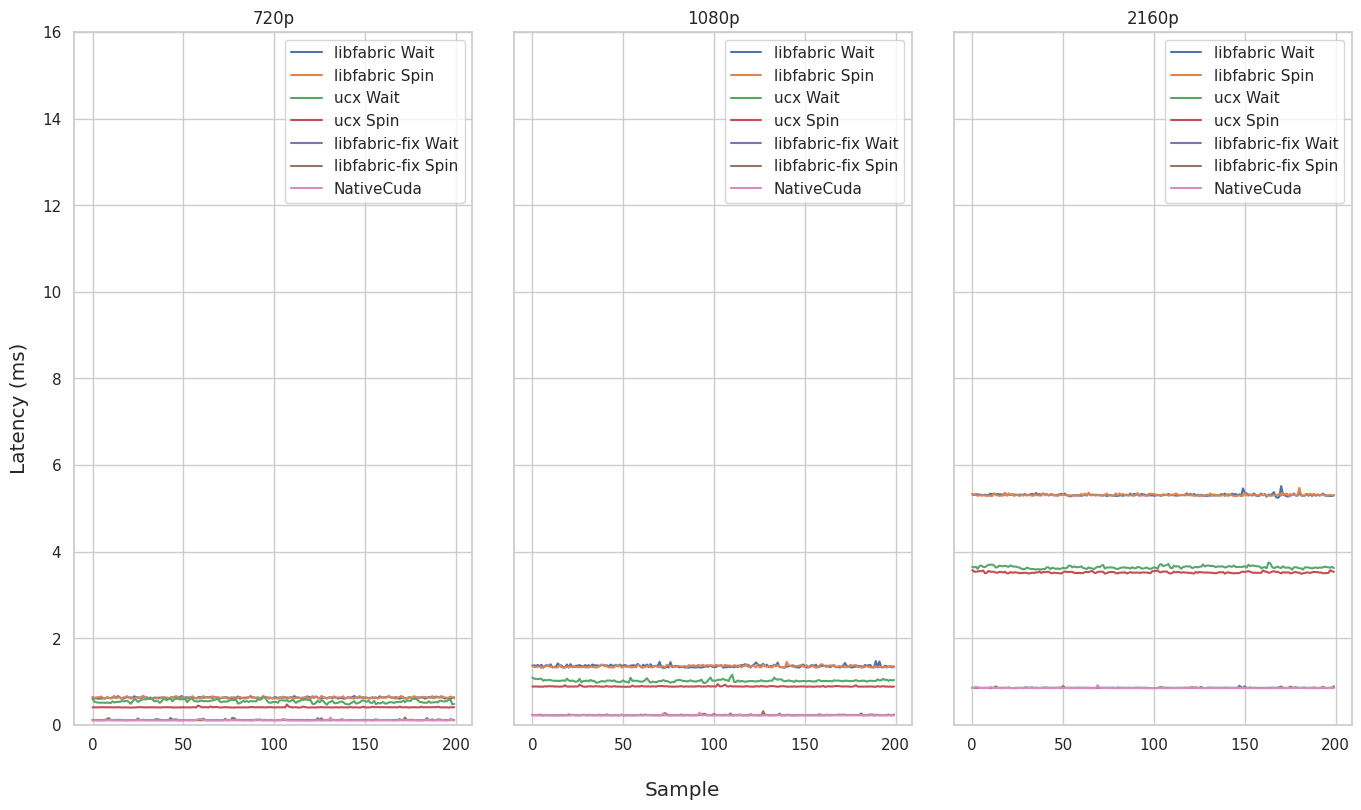

In [24]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
        
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.h2d, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")

    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric_fix, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric-fix {comp.value}")
        
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

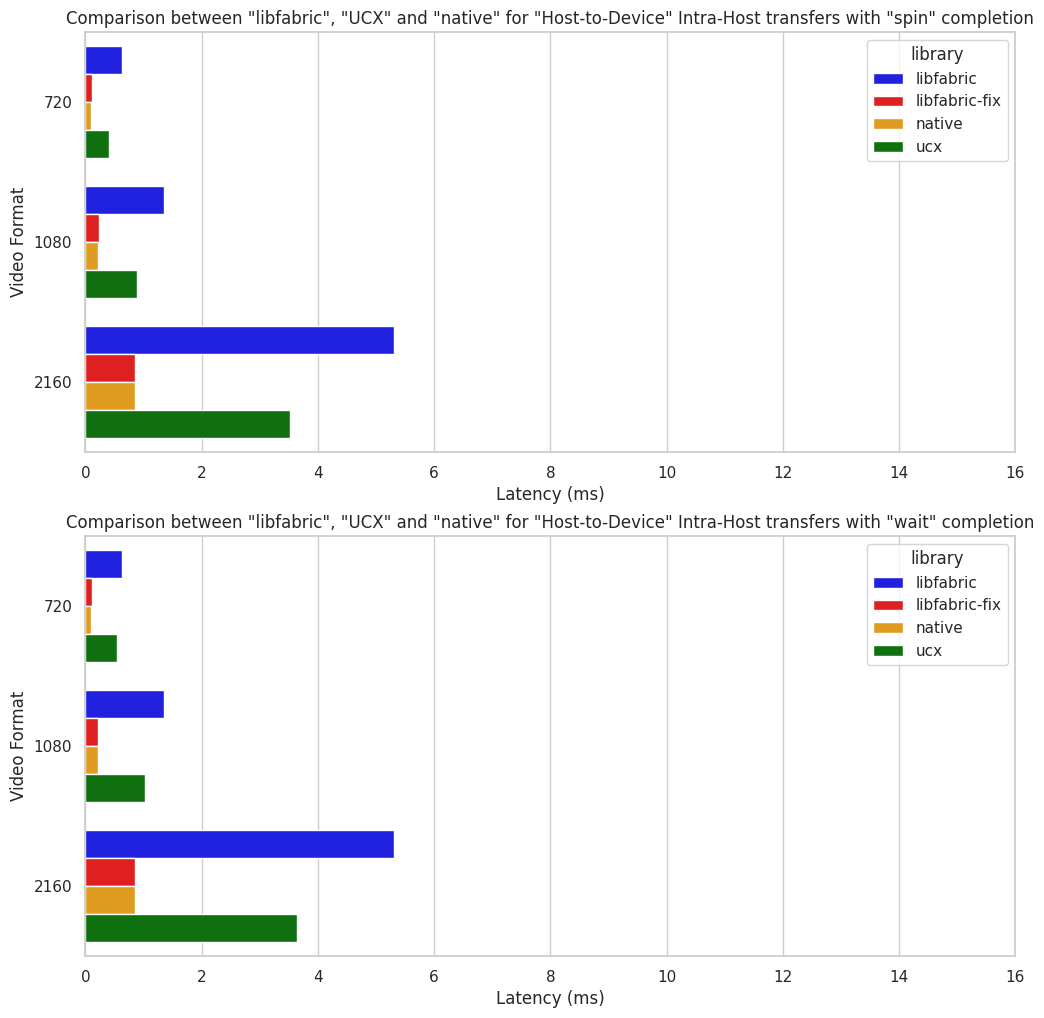

In [25]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "UCX" and "native" for "Host-to-Device" Intra-Host transfers with "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter((pl.col("completion") == comp.value) | (pl.col("completion") == "")), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [26]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["completion"], descending=True)
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["completion"], descending=True)
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["completion"], descending=True)

In [27]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (7, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ native        ┆            ┆ Host2Cuda ┆ 0.1053   ┆ 0.17    ┆ 0.0072  ┆ 0.0174    │
│ 720    ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 0.6269   ┆ 0.6674  ┆ 0.0138  ┆ 0.0809    │
│ 720    ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.1119   ┆ 0.1626  ┆ 0.0087  ┆ 0.0128    │
│ 720    ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 0.5429   ┆ 0.6457  ┆ 0.0346  ┆ 0.0135    │
│ 720    ┆ libfabric     ┆ Spin       ┆ Host2Cuda ┆ 0.6284   ┆ 0.6702  ┆ 0.0167  ┆ 0.0859    │
│ 720    ┆ libfabric-fix ┆ Spin       ┆ Host2Cuda ┆ 0.1109   ┆ 0.1694  ┆ 0.0084  ┆ 0.0112    │
│ 720    ┆ ucx           ┆ Spin       ┆ Host2Cuda ┆ 0.405    ┆ 0.4701  ┆ 0.0072  ┆ 0.0528    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eaa3df0c10>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eadd148790>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison for 1280x720 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eadd193190>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', val

In [28]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison for 1920x10880 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (7, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ native        ┆            ┆ Host2Cuda ┆ 0.2202   ┆ 0.2841  ┆ 0.0064  ┆ 0.031     │
│ 1080   ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 1.357    ┆ 1.4728  ┆ 0.029   ┆ 0.1675    │
│ 1080   ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.2248   ┆ 0.2548  ┆ 0.0045  ┆ 0.0223    │
│ 1080   ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 1.018    ┆ 1.1558  ┆ 0.0248  ┆ 0.0109    │
│ 1080   ┆ libfabric     ┆ Spin       ┆ Host2Cuda ┆ 1.3501   ┆ 1.4513  ┆ 0.0216  ┆ 0.1664    │
│ 1080   ┆ libfabric-fix ┆ Spin       ┆ Host2Cuda ┆ 0.2264   ┆ 0.3153  ┆ 0.0098  ┆ 0.023     │
│ 1080   ┆ ucx           ┆ Spin       ┆ Host2Cuda ┆ 0.8866   ┆ 0.9413  ┆ 0.0081  ┆ 0.1108    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eaa3dd99d0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eaa3d4a150>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison for 1920x10880 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eadd193590>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', v

In [29]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (7, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ native        ┆            ┆ Host2Cuda ┆ 0.8493   ┆ 0.9163  ┆ 0.0061  ┆ 0.106     │
│ 2160   ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 5.3106   ┆ 5.5132  ┆ 0.0257  ┆ 0.6394    │
│ 2160   ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.8542   ┆ 0.902   ┆ 0.0062  ┆ 0.0555    │
│ 2160   ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 3.6397   ┆ 3.749   ┆ 0.029   ┆ 0.0162    │
│ 2160   ┆ libfabric     ┆ Spin       ┆ Host2Cuda ┆ 5.3069   ┆ 5.47    ┆ 0.0209  ┆ 0.639     │
│ 2160   ┆ libfabric-fix ┆ Spin       ┆ Host2Cuda ┆ 0.8525   ┆ 0.8958  ┆ 0.0067  ┆ 0.0569    │
│ 2160   ┆ ucx           ┆ Spin       ┆ Host2Cuda ┆ 3.5198   ┆ 3.5709  ┆ 0.0163  ┆ 0.4254    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eade3997d0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eadd1498d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison for 3840x2160 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eaa3d3c950>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', va

## Device to Host Intra-Host

In [30]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2h], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/d2h-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda vs UCX for Device-to-Host transfers

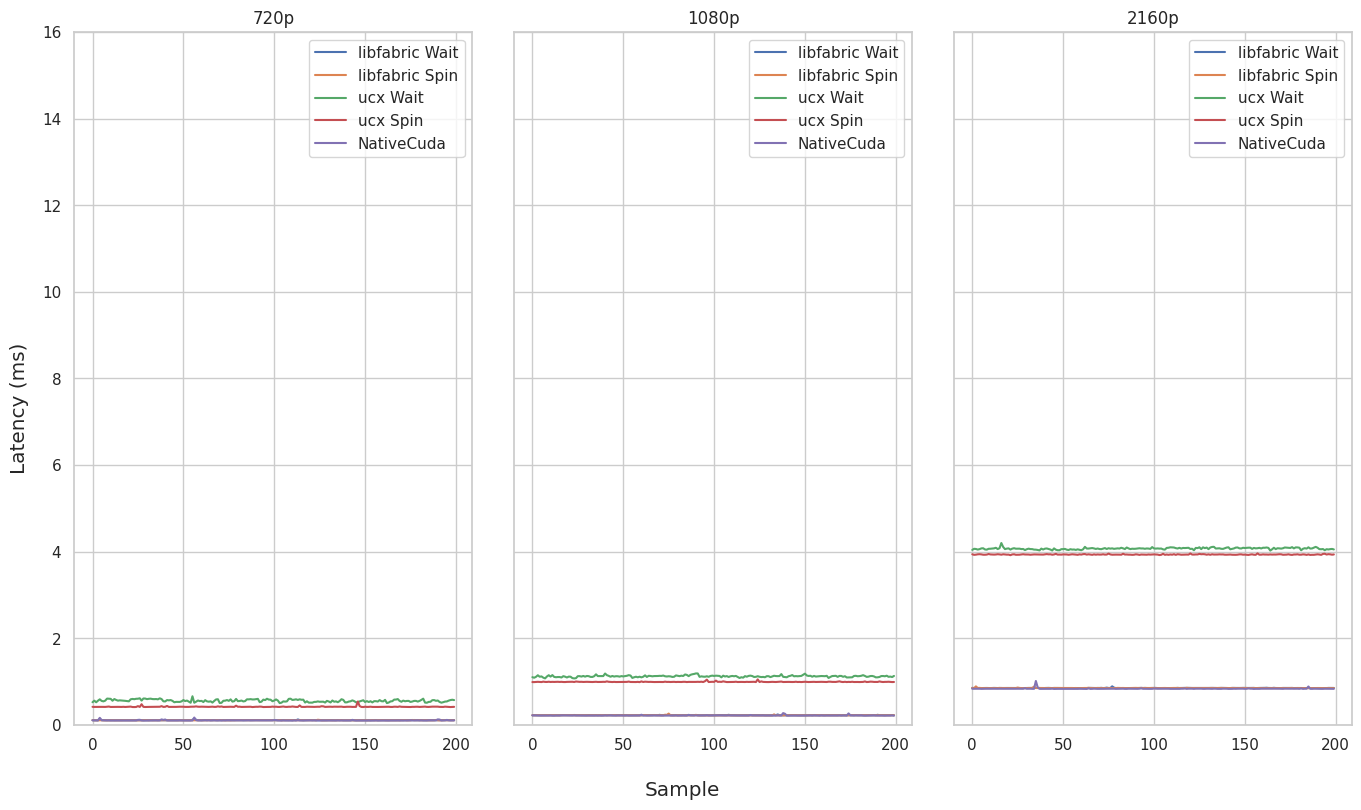

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
    for comp in config["completions"]:        
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2h, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

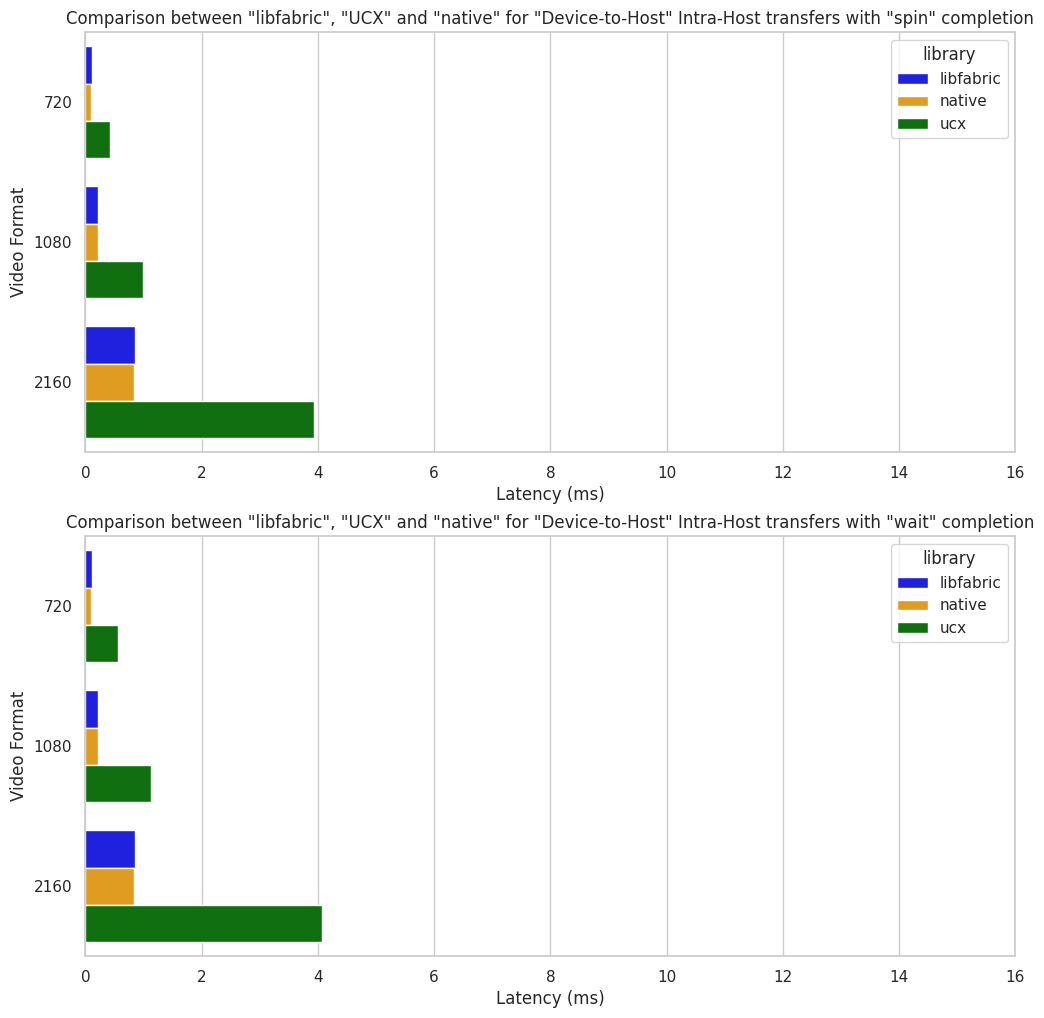

In [32]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"]).sort(pl.col("library"))
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "UCX" and "native" for "Device-to-Host" Intra-Host transfers with "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter((pl.col("completion") == comp.value) | (pl.col("completion") == "")), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [33]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["completion"], descending=True)
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["completion"], descending=True)
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["completion"], descending=True)

In [34]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison for 1280x720 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ native    ┆            ┆ Cuda2Host ┆ 0.1033   ┆ 0.1674  ┆ 0.0073  ┆ 0.0199    │
│ 720    ┆ libfabric ┆ Wait       ┆ Cuda2Host ┆ 0.106    ┆ 0.1429  ┆ 0.004   ┆ 0.0174    │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Host ┆ 0.556    ┆ 0.6592  ┆ 0.0287  ┆ 0.0199    │
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Host ┆ 0.1054   ┆ 0.1162  ┆ 0.0017  ┆ 0.0242    │
│ 720    ┆ ucx       ┆ Spin       ┆ Cuda2Host ┆ 0.417    ┆ 0.5379  ┆ 0.0107  ┆ 0.0546    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eaa3d16410>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eacf199390>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Host transfer latency comparison for 1280x720 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eace5f6550>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px'

In [35]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison for 1920x1080 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ native    ┆            ┆ Cuda2Host ┆ 0.2161   ┆ 0.2702  ┆ 0.0064  ┆ 0.0304    │
│ 1080   ┆ libfabric ┆ Wait       ┆ Cuda2Host ┆ 0.2212   ┆ 0.2392  ┆ 0.0022  ┆ 0.0368    │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Host ┆ 1.1206   ┆ 1.1865  ┆ 0.0196  ┆ 0.0126    │
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Host ┆ 0.2201   ┆ 0.2592  ┆ 0.0038  ┆ 0.0308    │
│ 1080   ┆ ucx       ┆ Spin       ┆ Cuda2Host ┆ 0.9918   ┆ 1.0487  ┆ 0.0068  ┆ 0.1237    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eaa3d7f690>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eacc0e3e10>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Host transfer latency comparison for 1920x1080 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eadd191810>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px

In [36]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison for 3840x2160 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ native    ┆            ┆ Cuda2Host ┆ 0.8343   ┆ 1.0124  ┆ 0.0136  ┆ 0.1042    │
│ 2160   ┆ libfabric ┆ Wait       ┆ Cuda2Host ┆ 0.8502   ┆ 0.8887  ┆ 0.0032  ┆ 0.1165    │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Host ┆ 4.0706   ┆ 4.1981  ┆ 0.0204  ┆ 0.0173    │
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Host ┆ 0.8495   ┆ 0.8877  ┆ 0.0039  ┆ 0.114     │
│ 2160   ┆ ucx       ┆ Spin       ┆ Cuda2Host ┆ 3.9329   ┆ 3.9591  ┆ 0.0061  ┆ 0.4745    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x71eaac05d090>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x71eaa3e1a910>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Host transfer latency comparison for 3840x2160 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x71eaa3ee2c90>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px

## Device to Device Intra-host Inter-GPU